In [37]:
import torch
from rfdetr import RFDETRSmall
from PIL import Image
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import json

import math
import torch.nn.functional as F

# Interference


In [38]:
model_path= "C:\\Users\\chris\\Documents\\GitHub\\outputs\\rfdetr_small_exp1\\checkpoint_best_total.pth"

In [39]:
model = RFDETRSmall(pretrain_weights=model_path,
    device="cuda"
)

[2026-03-16 19:58:57] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-16 19:58:57] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-16 19:58:58] [INFO] rf-detr - Loading pretrain weights


[2026-03-16 19:58:58] [WARNING] rf-detr - Reinitializing detection head with 1 classes based on pretrained weights, configured for 90.


In [40]:
print(type(model))
print(model)

<class 'rfdetr.detr.RFDETRSmall'>


In [41]:
print("wrapper:", type(model))
print("level 1:", type(model.model))

# sehr wahrscheinlich das echte torch-Modul:
print("has inner model:", hasattr(model.model, "model"))
if hasattr(model.model, "model"):
    print("level 2:", type(model.model.model))

wrapper: <class 'rfdetr.detr.RFDETRSmall'>
level 1: <class 'rfdetr.main.Model'>
has inner model: True
level 2: <class 'rfdetr.models.lwdetr.LWDETR'>


In [42]:
core_model = model.model.model

print("\n--- named modules of core model ---")
for name, module in core_model.named_modules():
    print(name, type(module))


--- named modules of core model ---
 <class 'rfdetr.models.lwdetr.LWDETR'>
transformer <class 'rfdetr.models.transformer.Transformer'>
transformer.decoder <class 'rfdetr.models.transformer.TransformerDecoder'>
transformer.decoder.layers <class 'torch.nn.modules.container.ModuleList'>
transformer.decoder.layers.0 <class 'rfdetr.models.transformer.TransformerDecoderLayer'>
transformer.decoder.layers.0.self_attn <class 'torch.nn.modules.activation.MultiheadAttention'>
transformer.decoder.layers.0.self_attn.out_proj <class 'torch.nn.modules.linear.NonDynamicallyQuantizableLinear'>
transformer.decoder.layers.0.dropout1 <class 'torch.nn.modules.dropout.Dropout'>
transformer.decoder.layers.0.norm1 <class 'torch.nn.modules.normalization.LayerNorm'>
transformer.decoder.layers.0.cross_attn <class 'rfdetr.models.ops.modules.ms_deform_attn.MSDeformAttn'>
transformer.decoder.layers.0.cross_attn.sampling_offsets <class 'torch.nn.modules.linear.Linear'>
transformer.decoder.layers.0.cross_attn.attent

In [43]:
target_layer = core_model.backbone[0].encoder.encoder.encoder.layer[11].attention.attention.value
target_layer

Linear(in_features=384, out_features=384, bias=True)

In [44]:
from PIL import Image
from torchvision import transforms


img_path = "A0015_1.3.6.1.4.1.14519.5.2.1.6655.2359.179873218428422946994591564339_16bit.png"
image = Image.open(img_path).convert("RGB")
transform = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

img_tensor = transform(image).unsqueeze(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_tensor = img_tensor.to(device)
core_model = core_model.to(device)
core_model.eval()

print(img_tensor.shape)

torch.Size([1, 3, 640, 640])


In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_tensor = img_tensor.to(device)
core_model = core_model.to(device)
core_model.eval()

LWDETR(
  (transformer): Transformer(
    (decoder): TransformerDecoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerDecoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (dropout1): Dropout(p=0, inplace=False)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (cross_attn): MSDeformAttn(
            (sampling_offsets): Linear(in_features=256, out_features=64, bias=True)
            (attention_weights): Linear(in_features=256, out_features=32, bias=True)
            (value_proj): Linear(in_features=256, out_features=256, bias=True)
            (output_proj): Linear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=2048, bias=True)
          (dropout): Dropout(p=0, inplace=False)
          (linear2): Linear(in_features=2048, out_features=256, bias=True

In [46]:
activations = {}

target_layer = core_model.transformer.decoder.layers[2].cross_attn

def forward_hook(module, inp, out):
    activations["value"] = out
    print("HOOK TYPE:", type(out))
    print("forward hook")
    print("num inputs:", len(inp))
    for i, x in enumerate(inp):
        if torch.is_tensor(x):
            print(f"inp[{i}].shape =", tuple(x.shape))
    
    if isinstance(out, tuple):
        print("Tuple length:", len(out))
        for i, x in enumerate(out):
            if hasattr(x, "shape"):
                print(f"  out[{i}] shape:", x.shape)
            else:
                print(f"  out[{i}] type:", type(x))
    else:
        if hasattr(out, "shape"):
            print("HOOK SHAPE:", out.shape)

handle = target_layer.register_forward_hook(forward_hook)

with torch.no_grad():
    outputs = core_model(img_tensor)

handle.remove()

print("Done.")

HOOK TYPE: <class 'torch.Tensor'>
forward hook
num inputs: 6
inp[0].shape = (1, 300, 256)
inp[1].shape = (1, 300, 1, 4)
inp[2].shape = (1, 1600, 256)
inp[3].shape = (1, 2)
inp[4].shape = (1,)
inp[5].shape = (1, 1600)
HOOK SHAPE: torch.Size([1, 300, 256])
Done.


In [47]:
outputs = core_model(img_tensor)

print(type(outputs))

if isinstance(outputs, dict):
    print("keys:", outputs.keys())
    for k, v in outputs.items():
        if hasattr(v, "shape"):
            print(k, v.shape)
        else:
            print(k, type(v))
else:
    print(outputs)

<class 'dict'>
keys: dict_keys(['pred_logits', 'pred_boxes', 'aux_outputs', 'enc_outputs'])
pred_logits torch.Size([1, 300, 2])
pred_boxes torch.Size([1, 300, 4])
aux_outputs <class 'list'>
enc_outputs <class 'dict'>


In [48]:
activations = {}

target_layer = core_model.backbone[0].projector.stages[0][0].cv2.conv
print("target_layer:", target_layer)

def forward_hook(module, inp, out):
    activations["value"] = out
    print("HOOK TYPE:", type(out))
    if hasattr(out, "shape"):
        print("HOOK SHAPE:", out.shape)

handle = target_layer.register_forward_hook(forward_hook)

with torch.no_grad():
    outputs = core_model(img_tensor)

handle.remove()

act = activations["value"]
print("final act shape:", act.shape)

target_layer: Conv2d(640, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
HOOK TYPE: <class 'torch.Tensor'>
HOOK SHAPE: torch.Size([1, 256, 40, 40])
final act shape: torch.Size([1, 256, 40, 40])


In [49]:
import torch

outputs = core_model(img_tensor)

pred_logits = outputs["pred_logits"]   # [1, 300, num_classes]
pred_boxes  = outputs["pred_boxes"]    # [1, 300, 4]

print("pred_logits:", pred_logits.shape)
print("pred_boxes :", pred_boxes.shape)

probs = pred_logits.softmax(-1)   # bei 2 Klassen hier meist [background?, object?] oder deine Klassenstruktur
scores, labels = probs[0].max(dim=-1)   # über Klassen

topk = 10
top_scores, top_idx = torch.topk(scores, k=topk)

print("\nTop predictions:")
for rank, q_idx in enumerate(top_idx):
    q = q_idx.item()
    print(
        f"rank={rank}  query={q}  score={scores[q].item():.4f}  "
        f"label={labels[q].item()}  box={pred_boxes[0, q].detach().cpu().numpy()}"
    )

pred_logits: torch.Size([1, 300, 2])
pred_boxes : torch.Size([1, 300, 4])

Top predictions:
rank=0  query=0  score=0.9992  label=0  box=[0.6781027  0.41551986 0.09159652 0.1439367 ]
rank=1  query=77  score=0.9240  label=0  box=[0.66789824 0.626517   0.25694835 0.23403506]
rank=2  query=16  score=0.9178  label=0  box=[0.6751821  0.4454777  0.07893725 0.08233003]
rank=3  query=61  score=0.9086  label=0  box=[0.6608173  0.45714983 0.05167539 0.05860141]
rank=4  query=2  score=0.9017  label=0  box=[0.6731147  0.4498805  0.10938662 0.23455483]
rank=5  query=39  score=0.8997  label=0  box=[0.6584897  0.51526403 0.09722176 0.1052887 ]
rank=6  query=212  score=0.8980  label=0  box=[0.51636267 0.56051844 0.95823413 0.6509211 ]
rank=7  query=76  score=0.8888  label=0  box=[0.657601   0.68193185 0.19270849 0.136397  ]
rank=8  query=3  score=0.8841  label=0  box=[0.66123396 0.52136654 0.07344706 0.09183167]
rank=9  query=99  score=0.8789  label=0  box=[0.72699416 0.5063648  0.13503747 0.09818378]


target_layer: Conv2d(640, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
FORWARD HOOK SHAPE: torch.Size([1, 256, 40, 40])
FORWARD:
queries     : torch.Size([1, 300, 256])
ref_points  : torch.Size([1, 300, 1, 4])
img_feats   : torch.Size([1, 1600, 256])
out         : torch.Size([1, 300, 256])
target_query: 0
target_class: 0
target_logit: 1.0996623039245605
BACKWARD HOOK SHAPE: torch.Size([1, 256, 40, 40])
act shape : torch.Size([1, 256, 40, 40])
grad shape: torch.Size([1, 256, 40, 40])
cam shape: torch.Size([40, 40])
cam min/max: 0.0 0.0


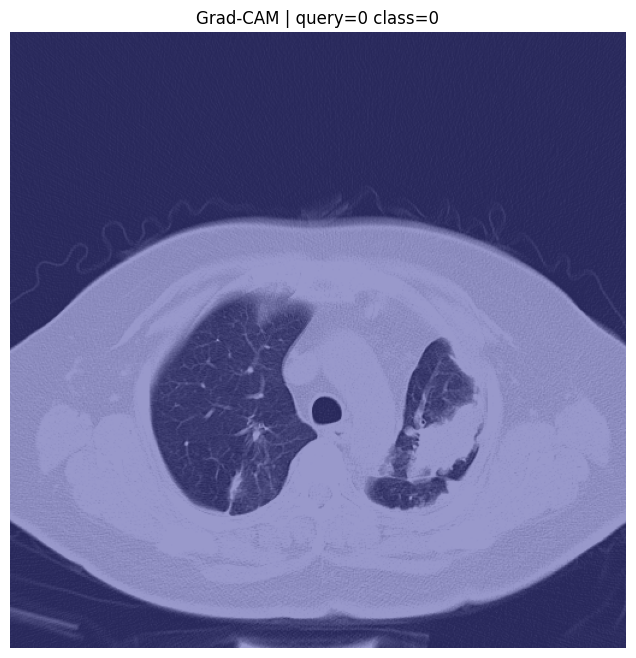

In [67]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# -----------------------------
# 1) Bild laden
# -----------------------------
img_path = "A0007_1.3.6.1.4.1.14519.5.2.1.6655.2359.118972525676913596910705207496_16bit.png"   # <-- anpassen
pil_img = Image.open(img_path).convert("RGB")

# -----------------------------
# 2) Hooks setzen
# -----------------------------
activations = {}
gradients = {}

target_layer = core_model.backbone[0].projector.stages[0][0].cv2.conv
print("target_layer:", target_layer)

def forward_hook(module, inp, out):
    activations["value"] = out
    print("FORWARD HOOK SHAPE:", out.shape)

def backward_hook(module, grad_input, grad_output):
    gradients["value"] = grad_output[0]
    print("BACKWARD HOOK SHAPE:", grad_output[0].shape)

fwd_handle = target_layer.register_forward_hook(forward_hook)
bwd_handle = target_layer.register_full_backward_hook(backward_hook)

# -----------------------------
# 3) Forward
# -----------------------------
core_model.zero_grad()
outputs = core_model(img_tensor)

pred_logits = outputs["pred_logits"]
pred_boxes  = outputs["pred_boxes"]

# beste Prediction fix nehmen
target_query = 0
target_class = 0

print("target_query:", target_query)
print("target_class:", target_class)
print("target_logit:", pred_logits[0, target_query, target_class].item())

# -----------------------------
# 4) Backward
# -----------------------------
target_score = pred_logits[0, target_query, target_class]
target_score.backward()

# -----------------------------
# 5) CAM berechnen
# -----------------------------
act = activations["value"]   # [1,256,40,40]
grad = gradients["value"]    # [1,256,40,40]

print("act shape :", act.shape)
print("grad shape:", grad.shape)

weights = grad.mean(dim=(2, 3), keepdim=True)          # [1,256,1,1]
cam = (weights * act).sum(dim=1, keepdim=True)         # [1,1,40,40]
cam = torch.relu(cam)

cam = cam[0, 0].detach().cpu()
cam = cam - cam.min()
cam = cam / (cam.max() + 1e-8)

print("cam shape:", cam.shape)
print("cam min/max:", cam.min().item(), cam.max().item())

# -----------------------------
# 6) Resize auf Bildgröße
# -----------------------------
cam_resized = F.interpolate(
    cam.unsqueeze(0).unsqueeze(0),
    size=(pil_img.size[1], pil_img.size[0]),
    mode="bilinear",
    align_corners=False
)[0, 0].numpy()

img_np = np.array(pil_img).astype(np.float32) / 255.0

# -----------------------------
# 7) Overlay anzeigen
# -----------------------------
plt.figure(figsize=(8, 8))
plt.imshow(img_np)
plt.imshow(cam_resized, cmap="jet", alpha=0.4)
plt.title(f"Grad-CAM | query={target_query} class={target_class}")
plt.axis("off")
plt.show()

# -----------------------------
# 8) hooks entfernen
# -----------------------------
fwd_handle.remove()
bwd_handle.remove()

grad mean abs: 3.0273396987468004e-05
grad min/max  : -0.008369998075067997 0.013805515132844448
weights mean abs: 8.78819810168352e-06
weights min/max  : -4.134081973461434e-05 4.17034825659357e-05
raw_cam min/max: -0.0013488964177668095 -0.0001836250303313136
raw_cam mean   : -0.0009519395534880459


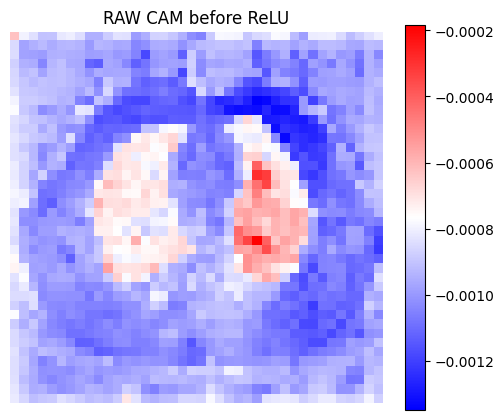

In [68]:
print("grad mean abs:", grad.abs().mean().item())
print("grad min/max  :", grad.min().item(), grad.max().item())

weights = grad.mean(dim=(2, 3), keepdim=True)
print("weights mean abs:", weights.abs().mean().item())
print("weights min/max  :", weights.min().item(), weights.max().item())

raw_cam = (weights * act).sum(dim=1, keepdim=True)
print("raw_cam min/max:", raw_cam.min().item(), raw_cam.max().item())
print("raw_cam mean   :", raw_cam.mean().item())

raw_cam_2d = raw_cam[0, 0].detach().cpu()

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
plt.imshow(raw_cam_2d.numpy(), cmap="bwr")
plt.colorbar()
plt.title("RAW CAM before ReLU")
plt.axis("off")
plt.show()

before norm min/max: -0.0013488964177668095 -0.0001836250303313136
after norm min/max: 0.0 0.9999914169311523


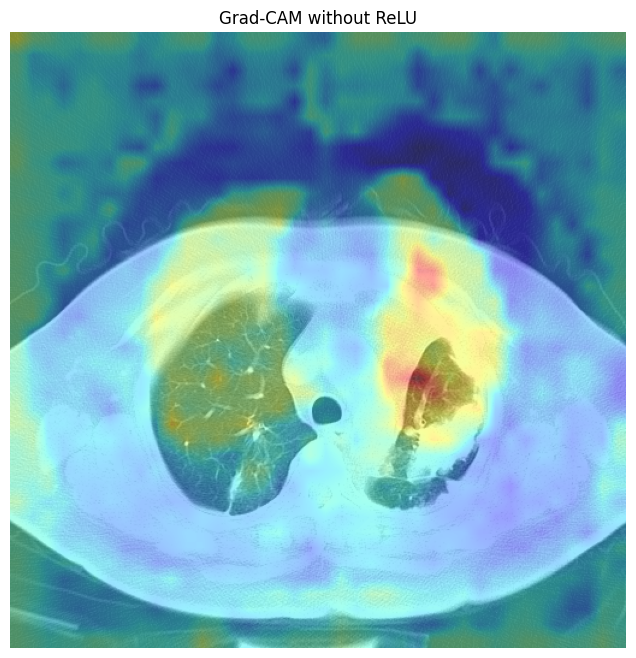

In [69]:
raw_cam = (weights * act).sum(dim=1, keepdim=True)
cam = raw_cam[0, 0].detach().cpu()

print("before norm min/max:", cam.min().item(), cam.max().item())

cam = cam - cam.min()
cam = cam / (cam.max() + 1e-8)

print("after norm min/max:", cam.min().item(), cam.max().item())

cam_resized = F.interpolate(
    cam.unsqueeze(0).unsqueeze(0),
    size=(pil_img.size[1], pil_img.size[0]),
    mode="bilinear",
    align_corners=False
)[0, 0].numpy()

plt.figure(figsize=(8, 8))
plt.imshow(np.array(pil_img).astype(np.float32) / 255.0)
plt.imshow(cam_resized, cmap="jet", alpha=0.4)
plt.title("Grad-CAM without ReLU")
plt.axis("off")
plt.show()

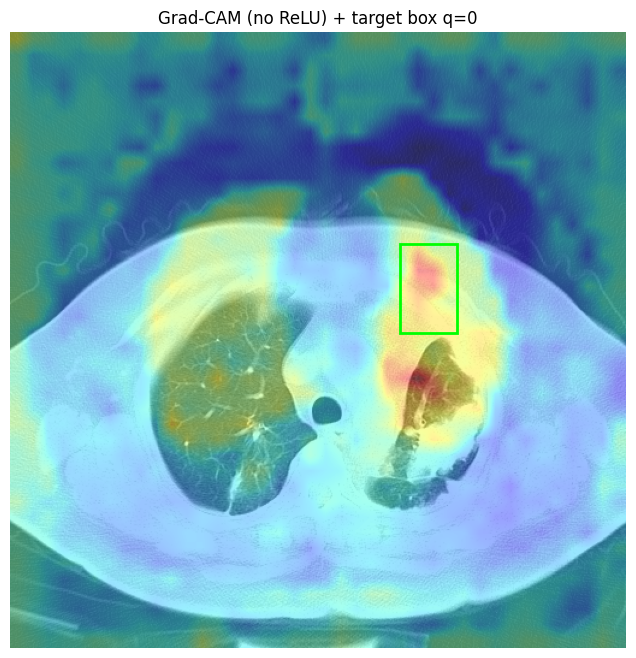

In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch.nn.functional as F

# -------- box von target_query holen --------
box = outputs["pred_boxes"][0, target_query].detach().cpu().numpy()
cx, cy, w, h = box

img_w, img_h = pil_img.size

x1 = (cx - w / 2) * img_w
y1 = (cy - h / 2) * img_h
bw = w * img_w
bh = h * img_h

# optional clamp
x1 = max(0, x1)
y1 = max(0, y1)
bw = min(bw, img_w - x1)
bh = min(bh, img_h - y1)

# -------- CAM resize --------
cam_resized = F.interpolate(
    cam.unsqueeze(0).unsqueeze(0),
    size=(img_h, img_w),
    mode="bilinear",
    align_corners=False
)[0, 0].numpy()

# -------- plot --------
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(np.array(pil_img).astype(np.float32) / 255.0)
ax.imshow(cam_resized, cmap="jet", alpha=0.4)

rect = patches.Rectangle(
    (x1, y1), bw, bh,
    linewidth=2, edgecolor="lime", facecolor="none"
)
ax.add_patch(rect)

ax.set_title(f"Grad-CAM (no ReLU) + target box q={target_query}")
ax.axis("off")
plt.show()

In [54]:
activations = {}

target_layer = core_model.transformer.decoder.layers[2]

def forward_hook(module, inp, out):
    activations["value"] = out
    print("HOOK TYPE:", type(out))
    if isinstance(out, tuple):
        print("tuple length:", len(out))
        for i, x in enumerate(out):
            if hasattr(x, "shape"):
                print(f"out[{i}] shape:", x.shape)
            else:
                print(f"out[{i}] type:", type(x))
    else:
        if hasattr(out, "shape"):
            print("HOOK SHAPE:", out.shape)

handle = target_layer.register_forward_hook(forward_hook)

with torch.no_grad():
    outputs = core_model(img_tensor)

handle.remove()

act = activations["value"]
print("\nFINAL TYPE:", type(act))
if isinstance(act, tuple):
    for i, x in enumerate(act):
        if hasattr(x, "shape"):
            print(f"final[{i}] shape:", x.shape)
        else:
            print(f"final[{i}] type:", type(x))
else:
    print("FINAL SHAPE:", act.shape)

HOOK TYPE: <class 'torch.Tensor'>
HOOK SHAPE: torch.Size([1, 300, 256])

FINAL TYPE: <class 'torch.Tensor'>
FINAL SHAPE: torch.Size([1, 300, 256])


In [55]:
activations = {}

target_layer = core_model.transformer.decoder.layers[2].cross_attn

def forward_hook(module, inp, out):
    print("=== CROSS ATTN HOOK ===")
    print("number of inputs:", len(inp))

    for i, x in enumerate(inp):
        if hasattr(x, "shape"):
            print(f"inp[{i}] shape:", x.shape)
        else:
            print(f"inp[{i}] type:", type(x))

    if isinstance(out, tuple):
        print("OUT is tuple, len =", len(out))
        for i, x in enumerate(out):
            if hasattr(x, "shape"):
                print(f"out[{i}] shape:", x.shape)
            else:
                print(f"out[{i}] type:", type(x))
        activations["value"] = out
    else:
        print("out shape:", out.shape if hasattr(out, "shape") else type(out))
        activations["value"] = out

handle = target_layer.register_forward_hook(forward_hook)

with torch.no_grad():
    outputs = core_model(img_tensor)

handle.remove()

=== CROSS ATTN HOOK ===
number of inputs: 6
inp[0] shape: torch.Size([1, 300, 256])
inp[1] shape: torch.Size([1, 300, 1, 4])
inp[2] shape: torch.Size([1, 1600, 256])
inp[3] shape: torch.Size([1, 2])
inp[4] shape: torch.Size([1])
inp[5] shape: torch.Size([1, 1600])
out shape: torch.Size([1, 300, 256])


In [56]:
import torch
import torch.nn.functional as F

target_layer = core_model.transformer.decoder.layers[2].cross_attn

saved = {}

def forward_hook(module, inp, out):
    # inp[2] = image features flattened: [B, 1600, 256]
    saved["feat"] = inp[2]
    saved["feat"].retain_grad()

    print("FORWARD:")
    print("queries     :", inp[0].shape)
    print("ref_points  :", inp[1].shape)
    print("img_feats   :", inp[2].shape)
    print("out         :", out.shape)

handle = target_layer.register_forward_hook(forward_hook)

In [57]:
core_model.zero_grad()

outputs = core_model(img_tensor)

pred_logits = outputs["pred_logits"]   # [1, 300, num_classes]
pred_boxes  = outputs["pred_boxes"]

print("pred_logits:", pred_logits.shape)
print("pred_boxes :", pred_boxes.shape)

probs = pred_logits[0].softmax(-1)

top_scores, top_idx = probs[:, 0].sort(descending=True)   # Klasse 0
target_query = top_idx[0].item()
target_class = 0

print("target_query:", target_query)
print("target_score:", top_scores[0].item())

target = pred_logits[0, target_query, target_class]
print("target_logit:", target.item())

FORWARD:
queries     : torch.Size([1, 300, 256])
ref_points  : torch.Size([1, 300, 1, 4])
img_feats   : torch.Size([1, 1600, 256])
out         : torch.Size([1, 300, 256])
pred_logits: torch.Size([1, 300, 2])
pred_boxes : torch.Size([1, 300, 4])
target_query: 0
target_score: 0.9992068409919739
target_logit: 1.0996623039245605


In [58]:
target.backward()

In [59]:
feat = saved["feat"]              # [1, 1600, 256]
grad = saved["feat"].grad         # [1, 1600, 256]

print("feat shape:", feat.shape)
print("grad shape:", grad.shape)

feat = feat[0]    # [1600, 256]
grad = grad[0]    # [1600, 256]

# channel weights
weights = grad.mean(dim=0)        # [256]

# weighted sum over channels
cam_flat = (feat * weights).sum(dim=1)   # [1600]

print("cam_flat:", cam_flat.shape)

cam = cam_flat.reshape(40, 40).detach().cpu()

print("raw cam min/max:", cam.min().item(), cam.max().item())
print("raw cam mean   :", cam.mean().item())

# signed normalization
cam_signed = cam / (cam.abs().max() + 1e-8)

print("signed cam min/max:", cam_signed.min().item(), cam_signed.max().item())

feat shape: torch.Size([1, 1600, 256])
grad shape: torch.Size([1, 1600, 256])
cam_flat: torch.Size([1600])
raw cam min/max: -0.0019962755031883717 -0.00039900073898024857
raw cam mean   : -0.0013328524073585868
signed cam min/max: -0.9999949932098389 -0.19987158477306366


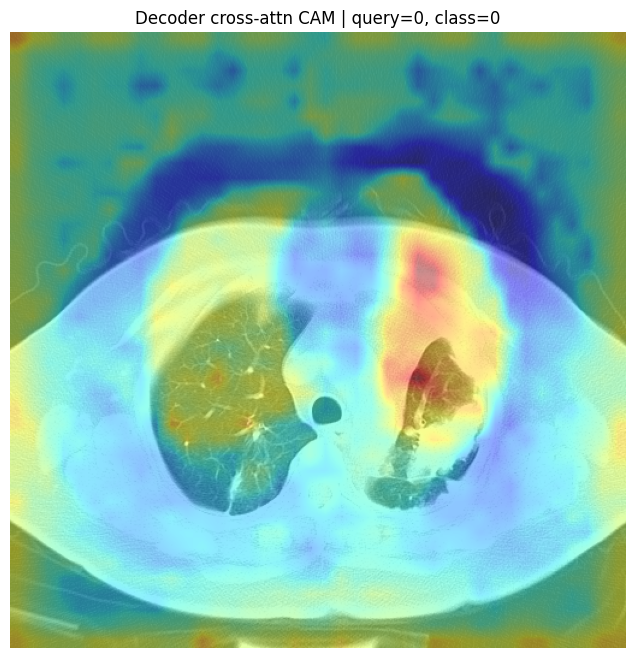

In [60]:
import matplotlib.pyplot as plt
import numpy as np

cam_up = F.interpolate(
    cam.unsqueeze(0).unsqueeze(0),
    size=pil_img.size[::-1],   # (H, W)
    mode="bilinear",
    align_corners=False
)[0, 0].numpy()

img_np = np.array(pil_img)

plt.figure(figsize=(8, 8))
plt.imshow(img_np)
plt.imshow(cam_up, cmap="jet", alpha=0.45)
plt.title(f"Decoder cross-attn CAM | query={target_query}, class={target_class}")
plt.axis("off")
plt.show()

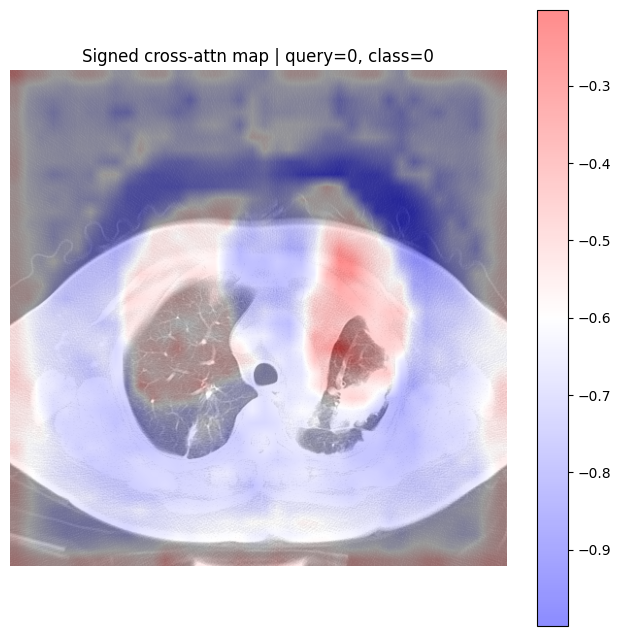

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

cam_up = F.interpolate(
    cam_signed.unsqueeze(0).unsqueeze(0),
    size=pil_img.size[::-1],
    mode="bilinear",
    align_corners=False
)[0, 0].numpy()

img_np = np.array(pil_img)

plt.figure(figsize=(8, 8))
plt.imshow(img_np)
plt.imshow(cam_up, cmap="bwr", alpha=0.45)   # rot/blau statt jet
plt.title(f"Signed cross-attn map | query={target_query}, class={target_class}")
plt.axis("off")
plt.colorbar()
plt.show()

FORWARD:
queries     : torch.Size([1, 300, 256])
ref_points  : torch.Size([1, 300, 1, 4])
img_feats   : torch.Size([1, 1600, 256])
out         : torch.Size([1, 300, 256])
FORWARD feat shape: torch.Size([1, 1600, 256])
target_logit: 1.0996623039245605
target_box  : [0.6781027  0.41551986 0.09159652 0.1439367 ]
target total: 1.7642402648925781
feat shape: torch.Size([1, 1600, 256])
grad shape: torch.Size([1, 1600, 256])
cam min/max before norm: -0.001992013305425644 -0.0003827949403785169


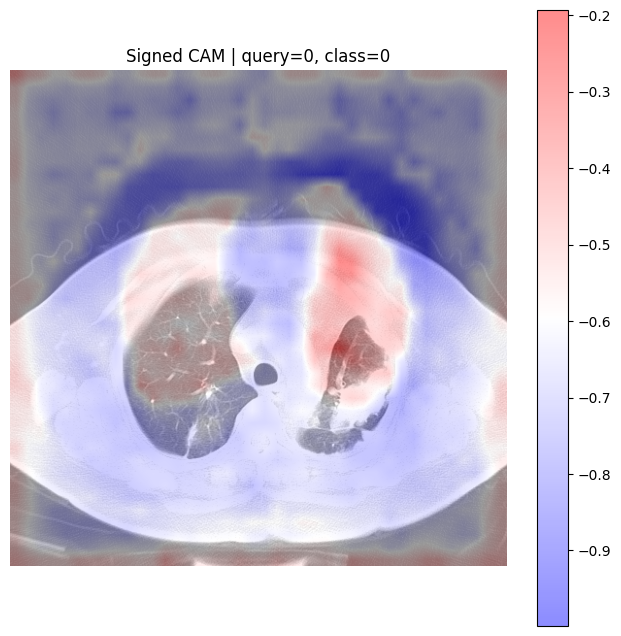

In [62]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

core_model.eval()
core_model.zero_grad()

# ---- target layer ----
target_layer = core_model.transformer.decoder.layers[2].cross_attn

saved = {}

def fwd_hook(module, inp, out):
    # inp[2] = value/features -> [B, 1600, 256]
    saved["feat"] = inp[2]
    print("FORWARD feat shape:", inp[2].shape)

def bwd_hook(module, grad_input, grad_output):
    # gradient wrt output of cross_attn -> [B, 300, 256]
    # for spatial map we actually want grad wrt saved feat
    pass

handle_fwd = target_layer.register_forward_hook(fwd_hook)

# IMPORTANT: input needs grad only if required downstream; model params already do
outputs = core_model(img_tensor)

pred_logits = outputs["pred_logits"]
pred_boxes  = outputs["pred_boxes"]

target_query = 0
target_class = 0

target_logit = pred_logits[0, target_query, target_class]
target_box   = pred_boxes[0, target_query]

target = target_logit + 0.5 * target_box.sum()

print("target_logit:", target_logit.item())
print("target_box  :", target_box.detach().cpu().numpy())
print("target total:", target.item())

# gradient wrt spatial feature tensor
feat = saved["feat"]
feat.retain_grad()

core_model.zero_grad()
target.backward(retain_graph=True)

handle_fwd.remove()

grad = feat.grad
print("feat shape:", feat.shape)
print("grad shape:", grad.shape)

# feat, grad: [1, 1600, 256]
weights = grad.mean(dim=1, keepdim=True)     # [1,1,256]
cam_flat = (feat * weights).sum(dim=-1)[0]   # [1600]

print("cam min/max before norm:", cam_flat.min().item(), cam_flat.max().item())

# no ReLU first
cam = cam_flat.reshape(40, 40).detach().cpu()

cam_signed = cam / (cam.abs().max() + 1e-8)

cam_up = F.interpolate(
    cam_signed.unsqueeze(0).unsqueeze(0),
    size=pil_img.size[::-1],
    mode="bilinear",
    align_corners=False
)[0, 0].numpy()

img_np = np.array(pil_img)

plt.figure(figsize=(8, 8))
plt.imshow(img_np)
plt.imshow(cam_up, cmap="bwr", alpha=0.45)
plt.title(f"Signed CAM | query={target_query}, class={target_class}")
plt.axis("off")
plt.colorbar()
plt.show()